# H2 Town01 Route 01

In [2]:
import os
import re
from collections import defaultdict
from typing import List

def analyze_files(directory, ignore_list: List[str] = None):
    file_info = defaultdict(lambda: [0, set()])

    # Regular expression to find and remove six consecutive digits
    pattern = re.compile(r'(.*?)[0-9]{6}(.*)')

    # Iterate through all files in the directory (ignore subdirectories)
    for file_name in os.listdir(directory):
        # Construct the full path
        full_path = os.path.join(directory, file_name)
        # Skip if it's not a file
        if not os.path.isfile(full_path):
            continue
        # Skip files that contain any of the ignore substrings
        if ignore_list and any(ignore_text in file_name for ignore_text in ignore_list):
            continue
        # Split the file name and extension
        name, ext = os.path.splitext(file_name)
        # Remove the six consecutive digits
        modified_name = pattern.sub(r'\1\2', name)
        # Update the file info dictionary
        file_info[modified_name][0] += 1
        file_info[modified_name][1].add(ext)

    # Convert sets to lists for better readability
    file_info = {k: (v[0], list(v[1])) for k, v in file_info.items()}

    return file_info

In [6]:
directory = '/data-net/ted/H2/H2_1_1/'

file_analysis = analyze_files(directory, ignore_list=['flow', 'warped', 'overlay', '.tar', '.mp4', '_frame', 'AM_image'])

In [7]:
print(f'{len(file_analysis)} total file types:')
for k, v in file_analysis.items():
    print(f"\t{k}: \n\t\t{v[0]} files with extensions {v[1]}")


46 total file types:
	rgb_CloudyNoon_central: 
		18354 files with extensions ['.jpg']
	rgb_WetNoon_central: 
		18353 files with extensions ['.jpg']
	attention_mirror_left: 
		18951 files with extensions ['.npz']
	rgb_left: 
		18290 files with extensions ['.jpg']
	semantic_segmentation_right: 
		18290 files with extensions ['.png']
	rgb_central: 
		18291 files with extensions ['.jpg']
	rgb_HardRainNoon_central: 
		18354 files with extensions ['.jpg']
	rgb_ClearSunset_left: 
		18331 files with extensions ['.jpg']
	depth_mirror_right: 
		18290 files with extensions ['.png']
	rgb_MidRainSunset_mirror_left: 
		18353 files with extensions ['.jpg']
	rgb_mirror_left: 
		18290 files with extensions ['.jpg']
	semantic_segmentation_mirror_right: 
		18290 files with extensions ['.png']
	cmd_fix_can_bus: 
		18291 files with extensions ['.json']
	rgb_MidRainSunset_left: 
		18353 files with extensions ['.jpg']
	rgb_ClearSunset_central: 
		18332 files with extensions ['.jpg']
	depth_right: 
		18290 fi

## Get the averages

In [6]:
import numpy as np
import os
from typing import Union

def load_and_average_data(camera_id: str, 
                          directory: Union[str, os.PathLike],
                          normalize: bool = False) -> np.ndarray:
    # Filter files for the specific camera
    file_pattern = f"attention_{camera_id}"
    files = [f for f in os.listdir(directory) if f.startswith(file_pattern) and f.endswith('.npz')]
    
    # Initialize a list to store data from each file
    data_list = []
    
    # Loop through the filtered files and load the 'attention' data
    for filename in files:
        file_path = os.path.join(directory, filename)
        with np.load(file_path) as data:
            attention_data = data['attention']
            data_list.append(attention_data)
    
    # Convert the list of arrays into a single numpy array
    data_array = np.stack(data_list)
    
    # Compute the average along the 0th dimension (across all files)
    average_data = np.mean(data_array, axis=0)

    # Normalize s.t. the sum of all values is 1
    if normalize:
        average_data = average_data / (np.sum(average_data) + 1e-8)
    
    return average_data


In [7]:
import os
import numpy as np
from PIL import Image
from PIL import ImageFile
import matplotlib.pyplot as plt


ImageFile.LOAD_TRUNCATED_IMAGES = True


def load_images(directory, file_pattern):
    # List all files in the directory that match the file pattern
    files = [f for f in os.listdir(directory) if f.endswith('.jpg') and file_pattern in f and 'warped' not in f]
    images = []
    
    # Load each file as an image
    for filename in files:
        file_path = os.path.join(directory, filename)
        img = Image.open(file_path)
        images.append(np.array(img))
    
    return images

def compute_average_image(images):
    # Stack all images into a single numpy array
    image_stack = np.stack(images, axis=0)
    
    # Compute the average across all images
    average_image = np.mean(image_stack, axis=0)
    
    # Convert back to uint8 for proper RGB display
    return average_image.astype(np.uint8)


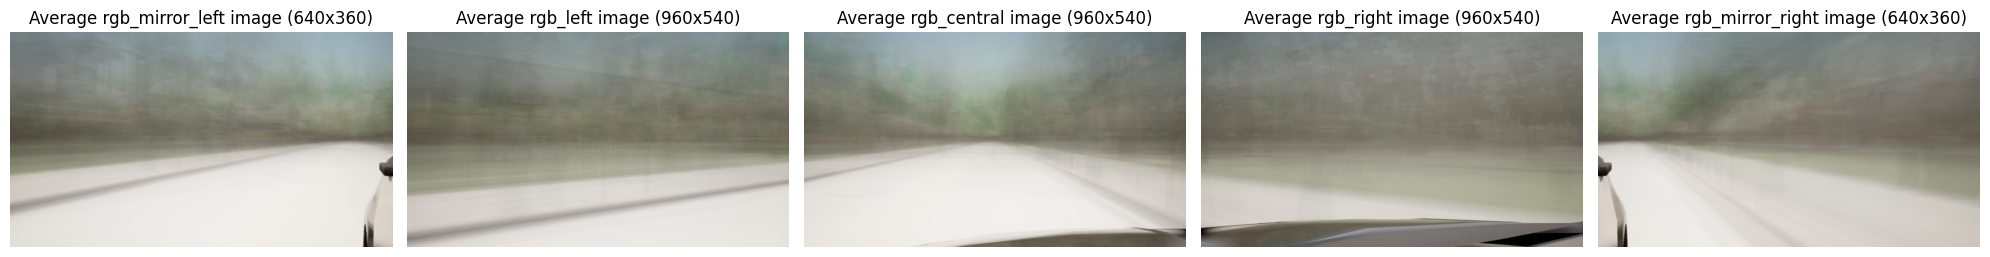

In [8]:
# Example usage
camera_idx = ['rgb_mirror_left', 'rgb_left', 'rgb_central', 'rgb_right', 'rgb_mirror_right']

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, idx in enumerate(camera_idx):
    images = load_images(directory, camera_idx[i])
    average_image = compute_average_image(images)
    axs[i].imshow(average_image)
    axs[i].set_title(f'Average {camera_idx[i]} image ({average_image.shape[1]}x{average_image.shape[0]})', fontsize=12)
    axs[i].axis('off')
plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import os
from typing import Union

def load_and_average_data(camera_id: str, 
                          directory: Union[str, os.PathLike],
                          normalize: bool = False) -> np.ndarray:
    # Filter files for the specific camera
    file_pattern = f"attention_{camera_id}"
    files = [f for f in os.listdir(directory) if f.startswith(file_pattern) and f.endswith('.npz')]
    
    # Initialize a list to store data from each file
    data_list = []
    
    # Loop through the filtered files and load the 'attention' data
    for filename in files:
        file_path = os.path.join(directory, filename)
        with np.load(file_path) as data:
            attention_data = data['attention']
            data_list.append(attention_data)
    
    # Convert the list of arrays into a single numpy array
    data_array = np.stack(data_list)
    
    # Compute the average along the 0th dimension (across all files)
    average_data = np.mean(data_array, axis=0)

    # Normalize s.t. the sum of all values is 1
    if normalize:
        average_data = average_data / (np.sum(average_data) + 1e-8)
    
    return average_data


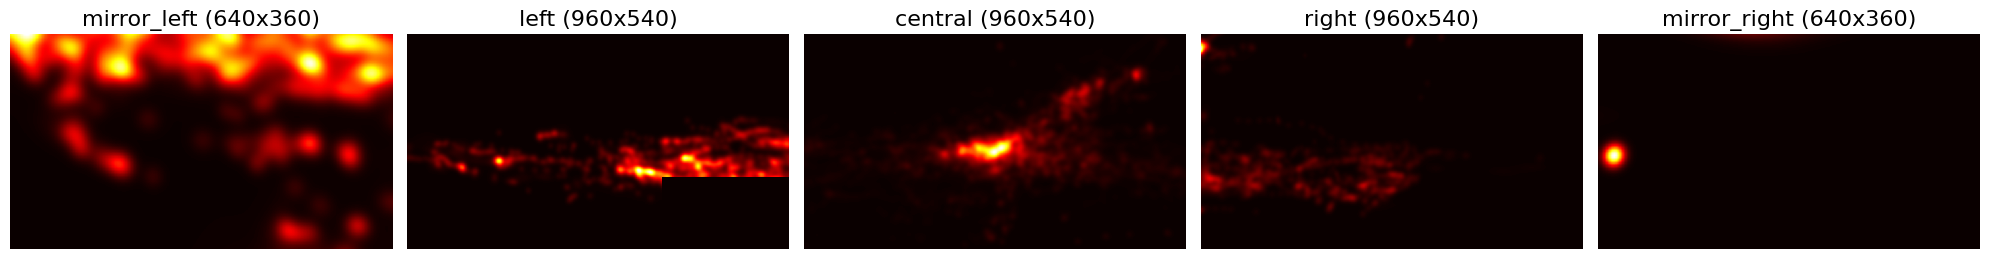

In [10]:
# For each of the cameras in the following list, get the average attention
# map, and then plot these in a grid (5 in total). Put the name at the
# top of each plot.

camera_idx = ['mirror_left', 'left', 'central', 'right', 'mirror_right']

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, idx in enumerate(camera_idx):
    average_data = load_and_average_data(idx, directory, True)
    axs[i].imshow(average_data, cmap='hot', interpolation='nearest')
    axs[i].set_title(f'{idx} ({average_data.shape[1]}x{average_data.shape[0]})', fontsize=16)
    axs[i].axis('off')
plt.tight_layout()
plt.show()

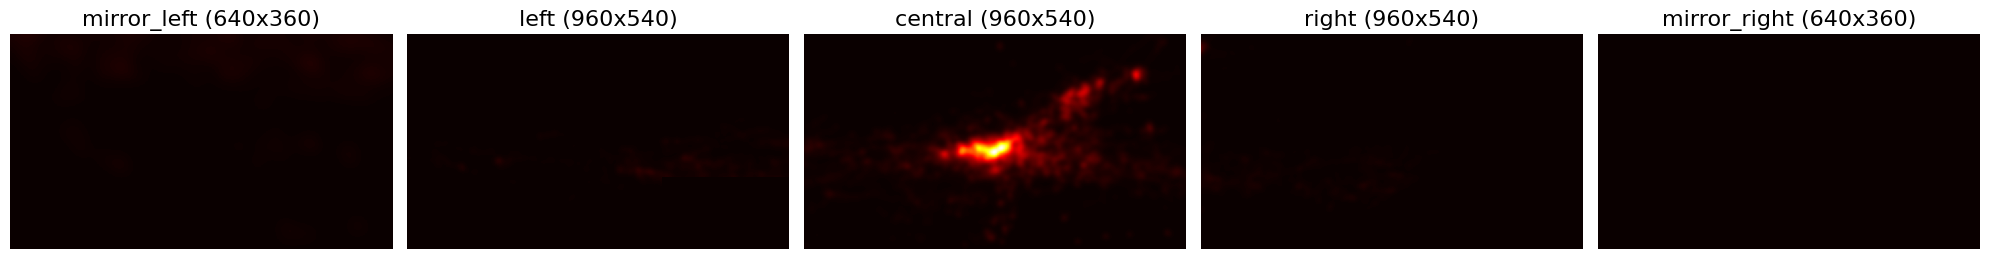

In [11]:
import numpy as np
import os
import matplotlib.pyplot as plt

def load_and_average_data(camera_id, directory, return_raw_average=False):
    # Assumes filenames are structured as 'attention_<camera_id>_*.npz'
    file_pattern = f"attention_{camera_id}"
    files = [f for f in os.listdir(directory) if f.startswith(file_pattern) and f.endswith('.npz')]
    
    # Initialize a list to store data from each file
    data_list = []
    
    # Load data
    for filename in files:
        file_path = os.path.join(directory, filename)
        with np.load(file_path) as data:
            attention_data = data['attention']
            data_list.append(attention_data)
    
    # Combine data from all files and average
    data_array = np.stack(data_list)
    average_data = np.mean(data_array, axis=0)
    
    if return_raw_average:
        return average_data, np.sum(average_data)  # Return the sum of the average for global normalization
    return average_data

def normalize_across_cameras(camera_idx, directory):
    all_averages = []
    total_sum = 0
    
    # First, load and average data for each camera and compute the total sum of these averages
    for idx in camera_idx:
        average_data, data_sum = load_and_average_data(idx, directory, return_raw_average=True)
        all_averages.append(average_data)
        total_sum += data_sum
    
    # Normalize each camera's average using the total sum
    normalized_data = [data / (total_sum + 1e-8) for data in all_averages]
    
    return normalized_data

# Example usage
normalized_averages = normalize_across_cameras(camera_idx, directory)

# Find global min and max for color scale normalization
global_min = min([np.min(data) for data in normalized_averages])
global_max = max([np.max(data) for data in normalized_averages])

# Visualization with fixed color scale
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, avg_data in enumerate(normalized_averages):
    im = axs[i].imshow(avg_data, cmap='hot', interpolation='nearest', vmin=global_min, vmax=global_max)
    axs[i].set_title(f'{camera_idx[i]} ({avg_data.shape[1]}x{avg_data.shape[0]})', fontsize=16)
    axs[i].axis('off')

# Adding a colorbar
# fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.02, pad=0.04)
plt.tight_layout()
plt.show()